In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import polars as pl

from backtester.dtypes import SpotInstrument
from backtester import io, samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
t0 = datetime(2023, 1, 1, tzinfo=timezone.utc)
tt = datetime(2023, 1, 15, tzinfo=timezone.utc)
tf = datetime(2023, 2, 28, tzinfo=timezone.utc)
dt = timedelta(hours=1)

In [5]:
path_rate = samplers.get_path_rate(t0, tf, dt)
paths_mark = samplers.get_paths_mark(t0, tf, dt)
bars_spot = paths_mark.pipe(samplers.to_bars_spot, ["binc", "cbse"], ["usd", "usdt"])
bars_option = paths_mark.pipe(samplers.to_bars_option, "drbt", "btc", "usd")

path_rate.show()
paths_mark.show()
bars_spot.show()
bars_option.show()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,0.05
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,0.049975
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,0.050034
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,0.049837
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,0.049975


time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100197.531221
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100093.260986
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",99800.4341
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",100218.651226
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",99987.515514


time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100197.531221,"""binc""","""usd""",99195.555909,101199.506533
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100093.260986,"""binc""","""usd""",99092.328376,101094.193596
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",99800.4341,"""binc""","""usd""",98802.429759,100798.438441
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",100218.651226,"""binc""","""usd""",99216.464713,101220.837738
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",99987.515514,"""binc""","""usd""",98987.640359,100987.390669


time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-01-06 08:00:00 UTC,2023-01-06 09:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 09:00:00 UTC,2023-01-06 10:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 10:00:00 UTC,2023-01-06 11:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 11:00:00 UTC,2023-01-06 12:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 12:00:00 UTC,2023-01-06 13:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0


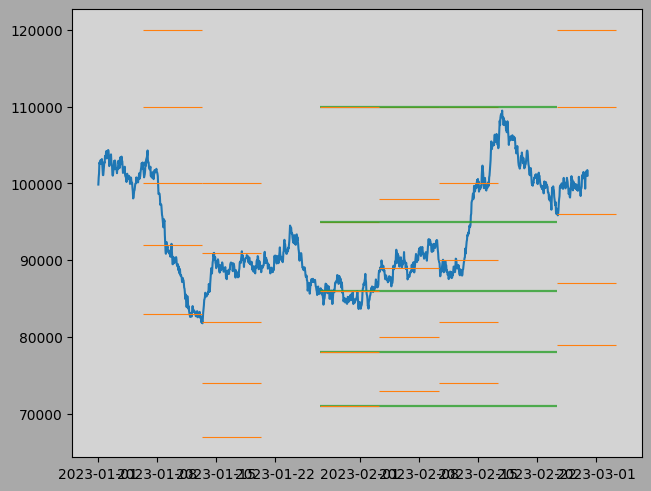

In [ ]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(
    paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
    paths_mark.filter(pl.col("name").eq("btc")).collect()["price"],
)
for k, tl, te in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    dw = abs((te - tl) - timedelta(days=7))
    dm = abs((te - tl) - timedelta(days=30))
    dq = abs((te - tl) - timedelta(days=90))

    alphas = {dw: 1.0, dm: 0.8, dq: 0.2}
    colors = {dw: "tab:orange", dm: "tab:green", dq: "tab:red"}
    widths = {dw: 0.8, dm: 1.6, dq: 3.2}

    a = alphas[min(alphas.keys())]
    c = colors[min(colors.keys())]
    w = widths[min(widths.keys())]

    ax.hlines(k, tl, te, alpha=a, color=c, linewidth=w)

In [8]:
target_option = io.get_target_option(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "c",
    SpotInstrument("cbse", "btc", "usd"),
    target_time=tt,
    target_delta=0.50,
    target_tenor=timedelta(days=30),
)
target_option

OptionInstrument(exchange='drbt', base='btc', quote='usd', strike=91000.0, listing=datetime.datetime(2023, 1, 13, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), expiry=datetime.datetime(2023, 1, 20, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), kind='c')

In [10]:
io.get_bars_option(bars_option, target_option, start_time=t0, end_time=tf).show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-01-13 08:00:00 UTC,2023-01-13 09:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 09:00:00 UTC,2023-01-13 10:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 10:00:00 UTC,2023-01-13 11:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 11:00:00 UTC,2023-01-13 12:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 12:00:00 UTC,2023-01-13 13:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0


In [11]:
io.get_bars_spot(
    bars_spot, SpotInstrument("cbse", "btc", "usd"), start_time=t0, end_time=tf
).show()

time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",99844.080815,"""cbse""","""usd""",98845.640007,100842.521623
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100783.531043,"""cbse""","""usd""",99775.695732,101791.366353
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",101321.081797,"""cbse""","""usd""",100307.870979,102334.292615
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",102701.875057,"""cbse""","""usd""",101674.856307,103728.893808
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",102538.730811,"""cbse""","""usd""",101513.343503,103564.118119


In [12]:
# NOTE: ~21.6s using duckdb for one month of data at dt=1h.
#       near-instant for Polars.
io._build_lf_priced(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "cbse",
    "btc",
    "usd",
).collect()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,spot,rate,iv_bid,iv_ask,iv_mark,px_bid,px_ask,px_mark,delta,gamma,vega,theta,rho
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-27 23:00:00 UTC,2023-02-28 00:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",101033.686584,0.04918,0.99,1.01,1.0,143.516036,160.242305,151.74447,0.040253,0.000009,836.313463,-45980.175152,35.755302
2023-02-27 22:00:00 UTC,2023-02-27 23:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",101729.416579,0.049327,0.99,1.01,1.0,178.412341,197.931721,188.028968,0.047966,0.00001,975.968973,-53006.218727,43.380574
2023-02-27 21:00:00 UTC,2023-02-27 22:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",100998.925302,0.049276,0.99,1.01,1.0,152.314834,169.817261,160.928006,0.041944,0.000009,875.121356,-46944.72969,38.148404
2023-02-27 20:00:00 UTC,2023-02-27 21:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",101387.504986,0.049427,0.99,1.01,1.0,174.243666,193.509483,183.733105,0.046673,0.00001,963.290803,-51058.769153,43.0945
2023-02-27 19:00:00 UTC,2023-02-27 20:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",101576.854534,0.04936,0.99,1.01,1.0,188.757243,209.158256,198.810962,0.049645,0.00001,1020.050643,-53427.773304,46.449088
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023-01-06 12:00:00 UTC,2023-01-06 13:00:00 UTC,"""drbt""","""btc""","""usd""",83000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",101193.263399,0.047598,0.99,1.01,1.0,383.820114,418.110594,400.783167,-0.063302,0.000009,1714.52396,-45748.71821,-126.651107
2023-01-06 11:00:00 UTC,2023-01-06 12:00:00 UTC,"""drbt""","""btc""","""usd""",83000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",100977.77573,0.047605,0.99,1.01,1.0,402.477253,437.845806,419.978741,-0.065797,0.000009,1768.427639,-46895.208733,-132.248851
2023-01-06 10:00:00 UTC,2023-01-06 11:00:00 UTC,"""drbt""","""btc""","""usd""",83000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",100784.631704,0.047564,0.99,1.01,1.0,420.324095,456.704834,438.331203,-0.068143,0.000009,1819.036947,-47941.266513,-137.613933
